In [1]:
import importlib
import sys
import numpy as np
from collections import Counter
import pandas as pd
import pickle

# performance imports for torch: torch kernel uses one core only.
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["TORCH_NUM_THREADS"] = "1" 

import torch

sys.path.insert(0, '..')
sys.path.insert(0, '../..')
sys.path.insert(0, '../../..')

In [2]:
import event_log_loader.new_event_log_loader_v2
importlib.reload(event_log_loader.new_event_log_loader_v2)
from event_log_loader.new_event_log_loader_v2 import PrefixesDataFrameLoader, EventLogLoader

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

np.random.seed(17)

event_log_location = '../../../../../../data/data/Sepsis.csv'

result_name = 'sepsis_all'

# dynamic categorical attributes
cat_dynamic = ['concept:name',
               'org:group',
               'lifecycle:transition']

# static categorical attributes
cat_static = ['Age',
              #
              'InfectionSuspected',
              #
              'Diagnose',
              'DiagnosticLacticAcid',
              'DiagnosticBlood',
              'DiagnosticArtAstrup',
              'DiagnosticIC',
              'DiagnosticSputum',
              'DiagnosticLiquor',
              'DiagnosticOther',
              'DiagnosticUrinarySediment',
              'DiagnosticECG',
              'DiagnosticUrinaryCulture',
              'DiagnosticXthorax',
              #
              'SIRSCritTachypnea',
              'SIRSCritHeartRate',
              'SIRSCriteria2OrMore',
              'SIRSCritTemperature',
              'SIRSCritLeucos',
              # 
              'Hypotensie',
              'Oligurie',          
              'Infusion',
              'Hypoxie',
              'DisfuncOrg',
              ]

# dynamic numerical attributes
num_dynamic = ['case_elapsed_time',
               'event_elapsed_time',
               'day_in_week',
               'seconds_in_day',
               'Leucocytes',
               'CRP',
               'LacticAcid']
num_dyn_log = []

# static numeric attributes
num_static = []

min_suffix_size = 5

# validation size
train_validation_size = 0.3
# 15% test size:
test_validation_size = 0.15

event_log_properties = {# case id
                        'case_name' : 'case:concept:name',
                        # activity
                        'concept_name' : 'concept:name',
                        # time values and computaitons
                        'timestamp_name' : 'time:timestamp',
                        'time_since_case_start_column' : 'case_elapsed_time',
                        'time_since_last_event_column' : 'event_elapsed_time',
                        'day_in_week_column' : 'day_in_week',
                        'seconds_in_day_column' : 'seconds_in_day',
                        # min suffix size for eos padding right
                        'min_suffix_size' : min_suffix_size,
                        # trian and test split
                        # train and test split
                        'train_validation_size' : train_validation_size,
                        'test_validation_size' : test_validation_size,
                        # window size for padding
                        'window_size' : 'auto',
                        # dynamic and static values
                        'categorical_columns' : cat_dynamic,
                        'static_categorical_columns' : cat_static,
                        'continuous_columns' : num_dynamic,
                        'continuous_positive_columns' : num_dyn_log,
                        'static_continuous_columns' : num_static}


## Create dataframes of prefixes

In [3]:
# object to create datframe of prefixes for petri-net repaly marking computation
pref_adopt_dataframe = PrefixesDataFrameLoader(event_log_location=event_log_location, event_log_properties=event_log_properties)

In [4]:
# output if necessary the raw dataframe: dynamic are lists, static values
raw_data = pref_adopt_dataframe.get_raw_dataframe()
raw_data

,case:concept:name,concept:name,org:group,lifecycle:transition,case_elapsed_time,event_elapsed_time,day_in_week,seconds_in_day,Leucocytes,CRP,...,SIRSCritTachypnea,SIRSCritHeartRate,SIRSCriteria2OrMore,SIRSCritTemperature,SIRSCritLeucos,Hypotensie,Oligurie,Infusion,Hypoxie,DisfuncOrg
0,A,"[ER Registration, Leucocytes, CRP, LacticAcid,...","[A, B, B, B, C, A, A, A, D, B, B, B, B, B, B, ...","[complete, complete, complete, complete, compl...","[0.0, 679.0, 679.0, 679.0, 1076.0, 1099.0, 100...","[nan, 679.0, 679.0, 679.0, 397.0, 23.0, 8987.0...","[2, 2, 2, 2, 2, 2, 2, 2, 2, 4, 4, 6, 6, 1, 1, ...","[40541, 41220, 41220, 41220, 41617, 41640, 506...","[nan, 9.6, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, 21.0, nan, nan, nan, nan, nan, nan,...",...,True,True,True,True,False,True,False,True,False,True
1,B,"[ER Registration, ER Triage, CRP, LacticAcid, ...","[A, C, B, B, B, A, A, A, F, B, B, E]","[complete, complete, complete, complete, compl...","[0.0, 775.0, 1896.0, 1896.0, 1896.0, 4281.0, 5...","[nan, 775.0, 1121.0, 1121.0, 1121.0, 2385.0, 1...","[6, 6, 6, 6, 6, 6, 6, 6, 6, 2, 4, 4]","[39864, 40639, 41760, 41760, 41760, 44145, 452...","[nan, nan, nan, nan, 13.8, nan, nan, nan, nan,...","[nan, nan, 240.0, nan, nan, nan, nan, nan, nan...",...,True,True,True,True,False,False,False,True,False,False
2,C,"[ER Registration, ER Triage, ER Sepsis Triage,...","[A, C, A, B, B, A, A, G, H, B, B, B, B, E]","[complete, complete, complete, complete, compl...","[0.0, 2154.0, 2164.0, 2191.0, 2191.0, 2263.0, ...","[nan, 2154.0, 10.0, 27.0, 27.0, 72.0, 7.0, 998...","[6, 6, 6, 6, 6, 6, 6, 6, 1, 1, 1, 4, 4, 5]","[70169, 72323, 72333, 72360, 72360, 72432, 724...","[nan, nan, nan, 15.4, nan, nan, nan, nan, nan,...","[nan, nan, nan, nan, 27.0, nan, nan, nan, nan,...",...,False,True,True,True,False,False,False,True,False,False
3,D,"[ER Registration, ER Triage, ER Sepsis Triage,...","[A, C, A, B, B, B, A, A, F, B, B, E, ?]","[complete, complete, complete, complete, compl...","[0.0, 864.0, 1494.0, 3480.0, 3480.0, 3480.0, 3...","[nan, 864.0, 630.0, 1986.0, 1986.0, 1986.0, 41...","[3, 3, 3, 3, 3, 3, 3, 3, 3, 5, 6, 1, 0]","[42720, 43584, 44214, 46200, 46200, 46200, 466...","[nan, nan, nan, nan, nan, 7.7, nan, nan, nan, ...","[nan, nan, nan, 171.0, nan, nan, nan, nan, nan...",...,True,True,True,True,False,False,False,True,False,False
4,E,"[ER Registration, ER Triage, ER Sepsis Triage,...","[A, C, A, A, B, B, B, A]","[complete, complete, complete, complete, compl...","[0.0, 65.0, 137.0, 934.0, 962.0, 962.0, 962.0,...","[nan, 65.0, 72.0, 797.0, 28.0, 28.0, 28.0, 299.0]","[3, 3, 3, 3, 3, 3, 3, 3]","[72898, 72963, 73035, 73832, 73860, 73860, 738...","[nan, nan, nan, nan, nan, 8.5, nan, nan]","[nan, nan, nan, nan, 265.0, nan, nan, nan]",...,True,True,True,True,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1044,HNA,"[ER Registration, ER Triage, ER Sepsis Triage,...","[A, C, A, B, B, B, A, W, B, B, B, B, B, B, B, ...","[complete, complete, complete, complete, compl...","[0.0, 255.0, 290.0, 369.0, 369.0, 369.0, 6518....","[nan, 255.0, 35.0, 79.0, 79.0, 79.0, 6149.0, 7...","[4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 5, ...","[37611, 37866, 37901, 37980, 37980, 37980, 441...","[nan, nan, nan, 2.0, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, 573.0, nan, nan, nan, 368...",...,True,True,True,True,False,False,False,True,False,False
1045,INA,"[ER Registration, ER Triage, ER Sepsis Triage]","[A, C, A]","[complete, complete, complete]","[0.0, 660.0, 3724.0]","[nan, 660.0, 3064.0]","[0, 0, 0]","[35027, 35687, 38751]","[nan, nan, nan]","[nan, nan, nan]",...,False,False,False,False,False,False,False,False,False,False
1046,JNA,"[ER Registration, ER Triage, ER Sepsis Triage]","[A, C, A]","[complete, complete, complete]","[0.0, 426.0, 440.0]","[nan, 426.0, 14.0]","[2, 2, 2]","[63619, 64045, 64059]","[nan, nan, nan]","[nan, nan, nan]",...,False,False,False,False,False,False,False,False,False,Fa

In [5]:
# prefix dataset for potential marking computation
train_pref_df = pref_adopt_dataframe.get_dataset('train')
train_pref_df

,case:concept:name,prefix_length,concept:name,org:group,lifecycle:transition,case_elapsed_time,event_elapsed_time,day_in_week,seconds_in_day,Leucocytes,...,SIRSCritTachypnea,SIRSCritHeartRate,SIRSCriteria2OrMore,SIRSCritTemperature,SIRSCritLeucos,Hypotensie,Oligurie,Infusion,Hypoxie,DisfuncOrg
0,A,1,[ER Registration],[A],[complete],[0.0],[nan],[2.0],[40541.0],[nan],...,True,True,True,True,False,True,False,True,False,True
1,A,2,"[ER Registration, Leucocytes]","[A, B]","[complete, complete]","[0.0, 679.0]","[nan, 679.0]","[2.0, 2.0]","[40541.0, 41220.0]","[nan, 9.600000381469727]",...,True,True,True,True,False,True,False,True,False,True
2,A,3,"[ER Registration, Leucocytes, CRP]","[A, B, B]","[complete, complete, complete]","[0.0, 679.0, 679.0]","[nan, 679.0, 679.0]","[2.0, 2.0, 2.0]","[40541.0, 41220.0, 41220.0]","[nan, 9.600000381469727, nan]",...,True,True,True,True,False,True,False,True,False,True
3,A,4,"[ER Registration, Leucocytes, CRP, LacticAcid]","[A, B, B, B]","[complete, complete, complete, complete]","[0.0, 679.0, 679.0, 679.0]","[nan, 679.0, 679.0, 679.0]","[2.0, 2.0, 2.0, 2.0]","[40541.0, 41220.0, 41220.0, 41220.0]","[nan, 9.600000381469727, nan, nan]",...,True,True,True,True,False,True,False,True,False,True
4,A,5,"[ER Registration, Leucocytes, CRP, LacticAcid,...","[A, B, B, B, C]","[complete, complete, complete, complete, compl...","[0.0, 679.0, 679.0, 679.0, 1076.0]","[nan, 679.0, 679.0, 679.0, 397.0]","[2.0, 2.0, 2.0, 2.0, 2.0]","[40541.0, 41220.0, 41220.0, 41220.0, 41617.0]","[nan, 9.600000381469727, nan, nan, nan]",...,True,True,True,True,False,True,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8208,HNA,29,"[ER Registration, ER Triage, ER Sepsis Triage,...","[A, C, A, B, B, B, A, W, B, B, B, B, B, B, B, ...","[complete, complete, complete, complete, compl...","[0.0, 255.0, 290.0, 369.0, 369.0, 369.0, 6518....","[nan, 255.0, 35.0, 79.0, 79.0, 79.0, 6149.0, 7...","[4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, ...","[37611.0, 37866.0, 37901.0, 37980.0, 37980.0, ...","[nan, nan, nan, 2.0, nan, nan, nan, nan, nan, ...",...,True,True,True,True,False,False,False,True,False,False
8209,HNA,30,"[ER Registration, ER Triage, ER Sepsis Triage,...","[A, C, A, B, B, B, A, W, B, B, B, B, B, B, B, ...","[complete, complete, complete, complete, compl...","[0.0, 255.0, 290.0, 369.0, 369.0, 369.0, 6518....","[nan, 255.0, 35.0, 79.0, 79.0, 79.0, 6149.0, 7...","[4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, ...","[37611.0, 37866.0, 37901.0, 37980.0, 37980.0, ...","[nan, nan, nan, 2.0, nan, nan, nan, nan, nan, ...",...,True,True,True,True,False,False,False,True,False,False
8210,JNA,1,[ER Registration],[A],[complete],[0.0],[nan],[2.0],[63619.0],[nan],...,False,False,False,False,False,False,False,False,False,False
8211,JNA,2,"[ER Registration, ER Triage]","[A, C]","[complete, complete]","[0.0, 426.0]","[nan, 426.0]","[2.0, 2.0]","[63619.0, 64045.0]","[nan, nan]",...,False,False,False,False,False,False,False,False,False,False


In [6]:
train_pref_df.to_csv('../../../../encoded_data_conformance_v2/Sepsis/prefix_for_replay/'+result_name+'_'+str(min_suffix_size)+'_train.csv', index=False)

In [7]:
# prefix dataset for potential marking computation
val_pref_df = pref_adopt_dataframe.get_dataset('val')
val_pref_df

,case:concept:name,prefix_length,concept:name,org:group,lifecycle:transition,case_elapsed_time,event_elapsed_time,day_in_week,seconds_in_day,Leucocytes,...,SIRSCritTachypnea,SIRSCritHeartRate,SIRSCriteria2OrMore,SIRSCritTemperature,SIRSCritLeucos,Hypotensie,Oligurie,Infusion,Hypoxie,DisfuncOrg
0,C,1,[ER Registration],[A],[complete],[0.0],[nan],[6.0],[70169.0],[nan],...,False,True,True,True,False,False,False,True,False,False
1,C,2,"[ER Registration, ER Triage]","[A, C]","[complete, complete]","[0.0, 2154.0]","[nan, 2154.0]","[6.0, 6.0]","[70169.0, 72323.0]","[nan, nan]",...,False,True,True,True,False,False,False,True,False,False
2,C,3,"[ER Registration, ER Triage, ER Sepsis Triage]","[A, C, A]","[complete, complete, complete]","[0.0, 2154.0, 2164.0]","[nan, 2154.0, 10.0]","[6.0, 6.0, 6.0]","[70169.0, 72323.0, 72333.0]","[nan, nan, nan]",...,False,True,True,True,False,False,False,True,False,False
3,C,4,"[ER Registration, ER Triage, ER Sepsis Triage,...","[A, C, A, B]","[complete, complete, complete, complete]","[0.0, 2154.0, 2164.0, 2191.0]","[nan, 2154.0, 10.0, 27.0]","[6.0, 6.0, 6.0, 6.0]","[70169.0, 72323.0, 72333.0, 72360.0]","[nan, nan, nan, 15.399999618530273]",...,False,True,True,True,False,False,False,True,False,False
4,C,5,"[ER Registration, ER Triage, ER Sepsis Triage,...","[A, C, A, B, B]","[complete, complete, complete, complete, compl...","[0.0, 2154.0, 2164.0, 2191.0, 2191.0]","[nan, 2154.0, 10.0, 27.0, 27.0]","[6.0, 6.0, 6.0, 6.0, 6.0]","[70169.0, 72323.0, 72333.0, 72360.0, 72360.0]","[nan, nan, nan, 15.399999618530273, nan]",...,False,True,True,True,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4581,INA,2,"[ER Registration, ER Triage]","[A, C]","[complete, complete]","[0.0, 660.0]","[nan, 660.0]","[0.0, 0.0]","[35027.0, 35687.0]","[nan, nan]",...,False,False,False,False,False,False,False,False,False,False
4582,INA,3,"[ER Registration, ER Triage, ER Sepsis Triage]","[A, C, A]","[complete, complete, complete]","[0.0, 660.0, 3724.0]","[nan, 660.0, 3064.0]","[0.0, 0.0, 0.0]","[35027.0, 35687.0, 38751.0]","[nan, nan, nan]",...,False,False,False,False,False,False,False,False,False,False
4583,LNA,1,[ER Registration],[L],[complete],[0.0],[nan],[2.0],[39028.0],[nan],...,False,False,False,False,False,False,False,False,False,False
4584,LNA,2,"[ER Registration, ER Triage]","[L, C]","[complete, complete]","[0.0, 231.0]","[nan, 231.0]","[2.0, 2.0]","[39028.0, 39259.0]","[nan, nan]",...,False,False,False,False,False,False,False,False,False,False


In [8]:
val_pref_df.to_csv('../../../../encoded_data_conformance_v2/Sepsis/prefix_for_replay/'+result_name+'_'+str(min_suffix_size)+'_val.csv', index=False)

In [9]:
# prefix dataset for potential marking computation
test_pref_df = pref_adopt_dataframe.get_dataset('test')
test_pref_df

,case:concept:name,prefix_length,concept:name,org:group,lifecycle:transition,case_elapsed_time,event_elapsed_time,day_in_week,seconds_in_day,Leucocytes,...,SIRSCritTachypnea,SIRSCritHeartRate,SIRSCriteria2OrMore,SIRSCritTemperature,SIRSCritLeucos,Hypotensie,Oligurie,Infusion,Hypoxie,DisfuncOrg
0,D,1,[ER Registration],[A],[complete],[0.0],[nan],[3.0],[42720.0],[nan],...,True,True,True,True,False,False,False,True,False,False
1,D,2,"[ER Registration, ER Triage]","[A, C]","[complete, complete]","[0.0, 864.0]","[nan, 864.0]","[3.0, 3.0]","[42720.0, 43584.0]","[nan, nan]",...,True,True,True,True,False,False,False,True,False,False
2,D,3,"[ER Registration, ER Triage, ER Sepsis Triage]","[A, C, A]","[complete, complete, complete]","[0.0, 864.0, 1494.0]","[nan, 864.0, 630.0]","[3.0, 3.0, 3.0]","[42720.0, 43584.0, 44214.0]","[nan, nan, nan]",...,True,True,True,True,False,False,False,True,False,False
3,D,4,"[ER Registration, ER Triage, ER Sepsis Triage,...","[A, C, A, B]","[complete, complete, complete, complete]","[0.0, 864.0, 1494.0, 3480.0]","[nan, 864.0, 630.0, 1986.0]","[3.0, 3.0, 3.0, 3.0]","[42720.0, 43584.0, 44214.0, 46200.0]","[nan, nan, nan, nan]",...,True,True,True,True,False,False,False,True,False,False
4,D,5,"[ER Registration, ER Triage, ER Sepsis Triage,...","[A, C, A, B, B]","[complete, complete, complete, complete, compl...","[0.0, 864.0, 1494.0, 3480.0, 3480.0]","[nan, 864.0, 630.0, 1986.0, 1986.0]","[3.0, 3.0, 3.0, 3.0, 3.0]","[42720.0, 43584.0, 44214.0, 46200.0, 46200.0]","[nan, nan, nan, nan, nan]",...,True,True,True,True,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2386,KNA,11,"[ER Registration, ER Triage, ER Sepsis Triage,...","[A, C, A, B, B, B, A, A, Q, B, B]","[complete, complete, complete, complete, compl...","[0.0, 1450.0, 1478.0, 2302.0, 2302.0, 2302.0, ...","[nan, 1450.0, 28.0, 824.0, 824.0, 824.0, 17798...","[3.0, 3.0, 3.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, ...","[84518.0, 85968.0, 85996.0, 420.0, 420.0, 420....","[nan, nan, nan, 9.399999618530273, nan, nan, n...",...,True,True,True,True,False,False,False,True,False,False
2387,KNA,12,"[ER Registration, ER Triage, ER Sepsis Triage,...","[A, C, A, B, B, B, A, A, Q, B, B, B]","[complete, complete, complete, complete, compl...","[0.0, 1450.0, 1478.0, 2302.0, 2302.0, 2302.0, ...","[nan, 1450.0, 28.0, 824.0, 824.0, 824.0, 17798...","[3.0, 3.0, 3.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, ...","[84518.0, 85968.0, 85996.0, 420.0, 420.0, 420....","[nan, nan, nan, 9.399999618530273, nan, nan, n...",...,True,True,True,True,False,False,False,True,False,False
2388,KNA,13,"[ER Registration, ER Triage, ER Sepsis Triage,...","[A, C, A, B, B, B, A, A, Q, B, B, B, B]","[complete, complete, complete, complete, compl...","[0.0, 1450.0, 1478.0, 2302.0, 2302.0, 2302.0, ...","[nan, 1450.0, 28.0, 824.0, 824.0, 824.0, 17798...","[3.0, 3.0, 3.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, ...","[84518.0, 85968.0, 85996.0, 420.0, 420.0, 420....","[nan, nan, nan, 9.399999618530273, nan, nan, n...",...,True,True,True,True,False,False,False,True,False,False
2389,KNA,14,"[ER Registration, ER Triage, ER Sepsis Triage,...","[A, C, A, B, B, B, A, A, Q, B, B, B, B, B]","[complete, complete, complete, complete, compl...","[0.0, 1450.0, 1478.0, 2302.0, 2302.0, 2302.0, ...","[nan, 1450.0, 28.0, 824.0, 824.0, 824.0, 17798...","[3.0, 3.0, 3.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, ...","[84518.0, 85968.0, 85996.0, 420.0, 420.0, 420....","[nan, nan, nan, 9.399999618530273, nan, nan, n...",...,True,True,True,True,False,False,False,True,False,False


In [10]:
test_pref_df.to_csv('../../../../encoded_data_conformance_v2/Sepsis/prefix_for_replay/'+result_name+'_'+str(min_suffix_size)+'_test.csv', index=False)

## Optional: Compute Petri Net replay markings of prefixes 

In [11]:
# Optional set list of ids the petri net should be executed:
unique_list_train = train_pref_df["case:concept:name"].dropna().unique().tolist()
unique_list_val = val_pref_df["case:concept:name"].dropna().unique().tolist()

case_ids = list(dict.fromkeys(unique_list_train + unique_list_val))

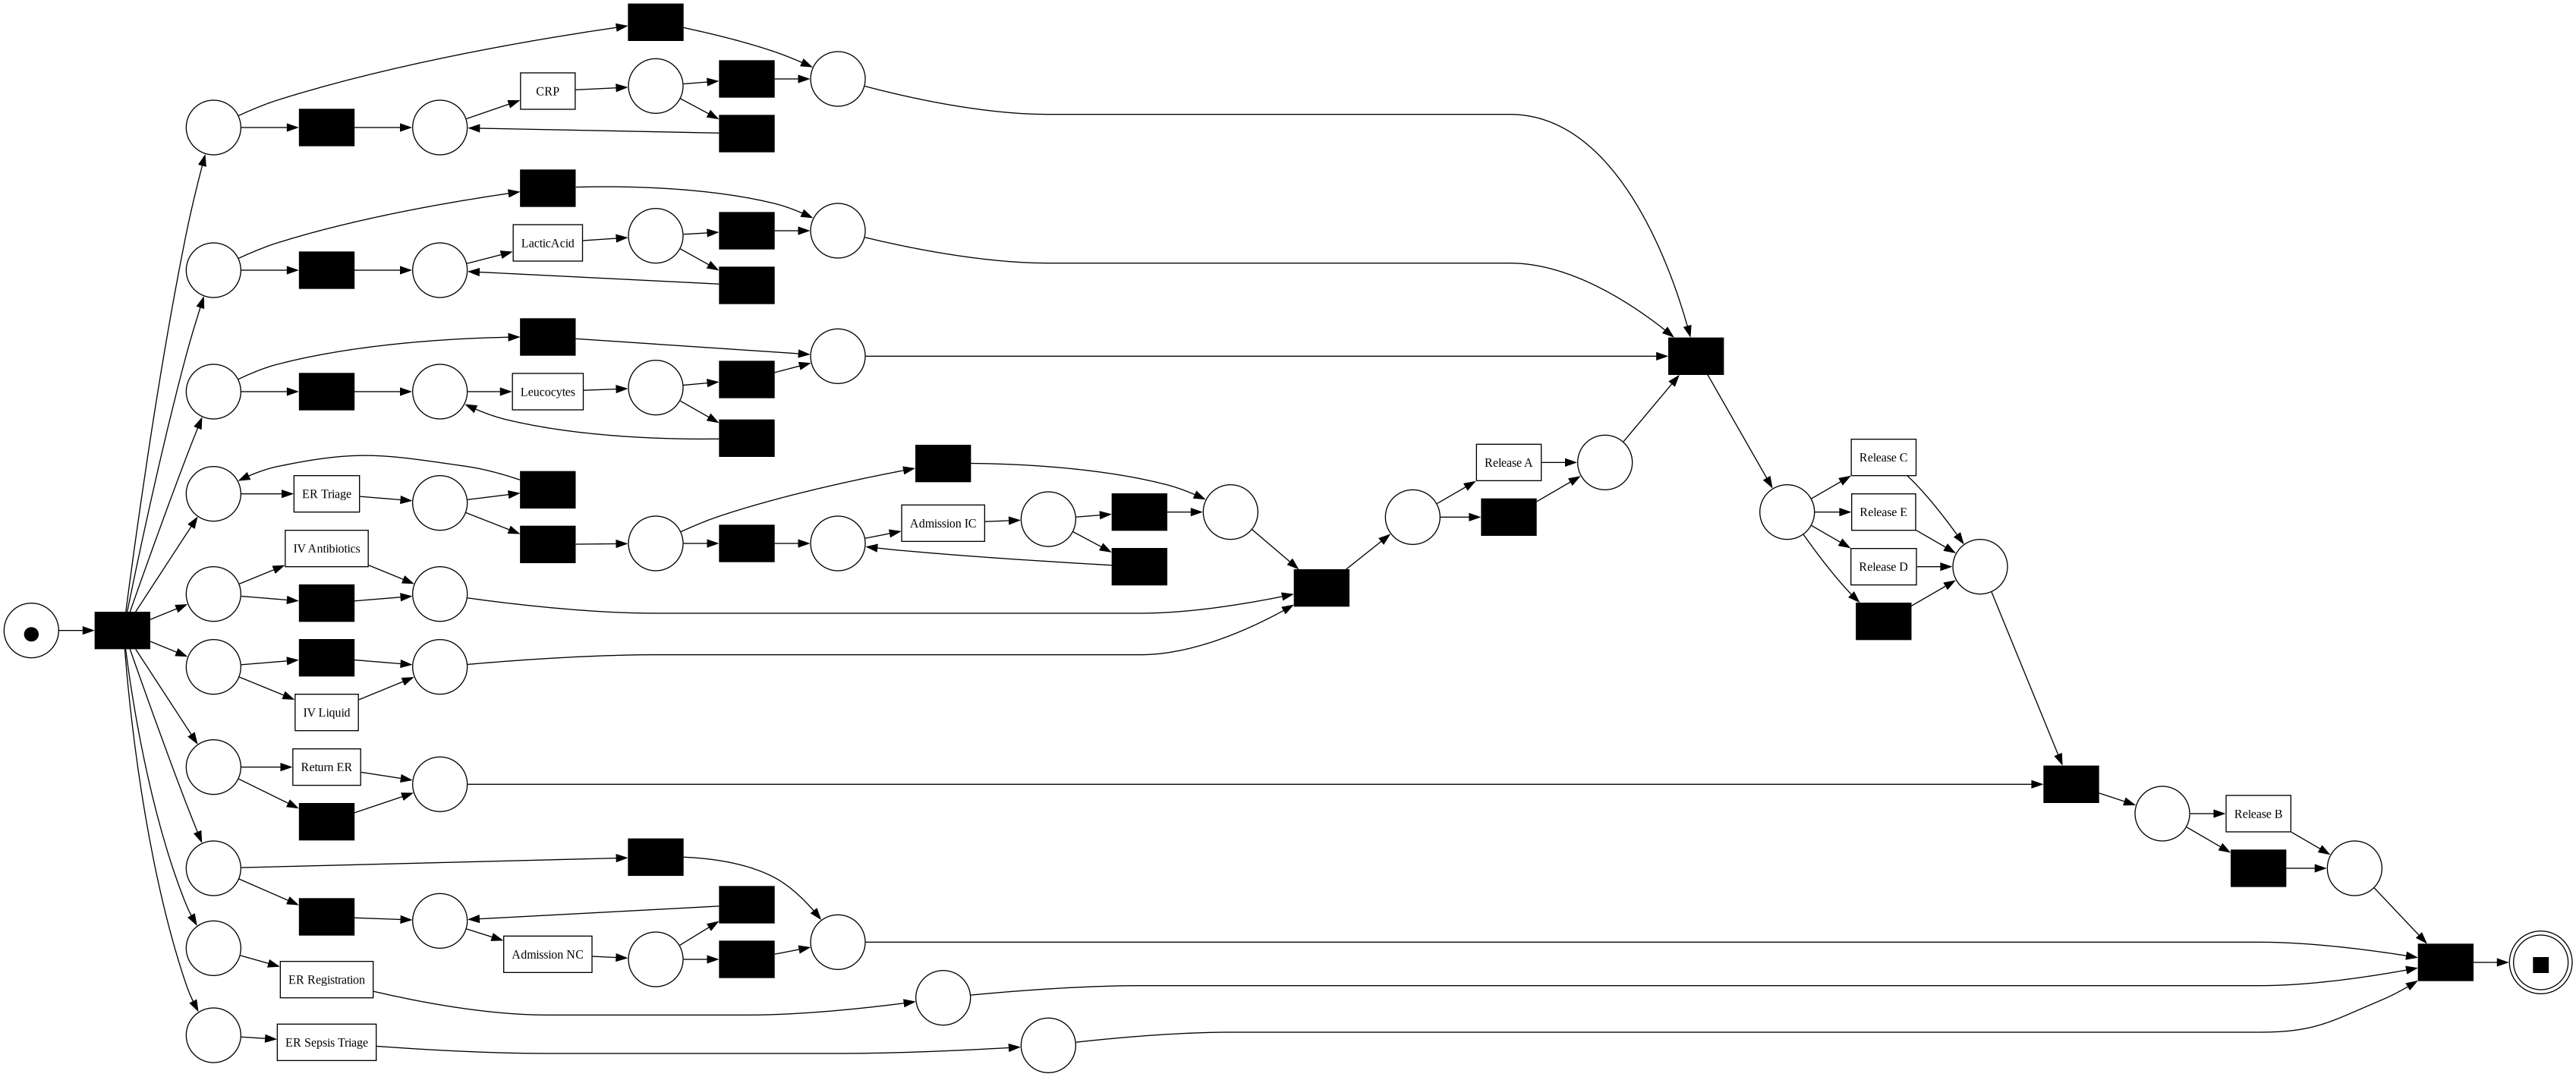

In [12]:
# Calculate and store markings:
import event_log_loader.petri_net_replay_markings
importlib.reload(event_log_loader.petri_net_replay_markings)
from event_log_loader.petri_net_replay_markings import InductiveMiner, PNReplayMarkings

# initialize the process 
miner = InductiveMiner(path_to_csv_log=event_log_location, case_id_col="case:concept:name", activity_col="concept:name", timestamp_col="time:timestamp", resource_col="org:group")
store_loc_file_path = '../../../../encoded_data_conformance_v2/Sepsis/prefix_for_replay/petri_net/sepsis.png'
net, im, fm = miner.discover_petri_net(visulaize=True,
                                       case_ids=case_ids,
                                       store_loc_file_path=store_loc_file_path)

# store discovered petri net objects next to the PNG
pkl_path = os.path.splitext(store_loc_file_path)[0] + '.pkl'
with open(pkl_path, 'wb') as f:
    pickle.dump((net, im, fm), f)

In [13]:
# train set markings
replayer_train = PNReplayMarkings(discovered_pn=(net, im, fm), prefix_df=train_pref_df, event_label="concept:name")

markings_train = replayer_train.get_markings_token_replay()

print("Amount markings: ", len(markings_train))
markings_counter_train = Counter(tuple(mark) for mark in markings_train)
markings_summary_train = ( pd.DataFrame([(list(mark), count) for mark, count in markings_counter_train.items()], columns=["marking", "count"]).sort_values("count", ascending=False).reset_index(drop=True))
markings_summary_train

Amount markings:  8213


,marking,count
0,"[p_5, p_32, p_10, p_45, p_22, p_40, p_51, p_27...",552
1,"[p_5, p_32, p_10, p_22, p_40, p_51, p_27, p_17...",511
2,"[p_5, p_32, p_22, p_40, p_51, p_27, p_17, p_13...",445
3,"[p_17, p_13, p_46, p_11, p_35, p_52, p_41, p_8...",168
4,"[p_17, p_13, p_46, p_11, p_35, p_52, p_41, p_8...",160
...,...,...
1100,"[p_5, p_22, p_17, p_11, p_13, p_46, p_52, p_41...",1
1101,"[p_5, p_17, p_11, p_13, p_46, p_52, p_41, p_30...",1
1102,"[p_5, p_17, p_11, p_13, p_52, p_41, p_30, p_35...",1
1103,"[p_5, p_17, p_11, p_13, p_52, p_41, p_30, p_25...",1


In [14]:
# train set markings
replayer_val = PNReplayMarkings(discovered_pn=(net, im, fm), prefix_df=val_pref_df, event_label="concept:name")

markings_val = replayer_val.get_markings_token_replay()

print("Amount markings: ", len(markings_val))
markings_counter_val = Counter(tuple(mark) for mark in markings_val)
markings_summary_val = (pd.DataFrame([(list(mark), count) for mark, count in markings_counter_val.items()], columns=["marking", "count"]).sort_values("count", ascending=False).reset_index(drop=True))
markings_summary_val

Amount markings:  4586


,marking,count
0,"[p_5, p_32, p_10, p_45, p_22, p_40, p_51, p_27...",292
1,"[p_5, p_32, p_10, p_22, p_40, p_51, p_27, p_17...",269
2,"[p_5, p_32, p_22, p_40, p_51, p_27, p_17, p_13...",238
3,"[p_17, p_13, p_46, p_11, p_35, p_52, p_41, p_8...",105
4,"[p_17, p_13, p_46, p_11, p_35, p_52, p_41, p_8...",90
...,...,...
851,"[p_13, p_11, p_8, p_25, p_30, p_38, p_18, p_35]",1
852,"[p_32, p_40, p_51, p_17, p_13, p_46, p_25, p_1...",1
853,"[p_32, p_40, p_51, p_17, p_13, p_46, p_30, p_2...",1
854,"[p_51, p_17, p_13, p_46, p_11, p_25, p_35, p_4...",1


In [15]:
# train set markings
replayer_test = PNReplayMarkings(discovered_pn=(net, im, fm), prefix_df=test_pref_df, event_label="concept:name")

markings_test = replayer_test.get_markings_token_replay()

print("Amount markings: ", len(markings_test))
markings_counter_test = Counter(tuple(mark) for mark in markings_test)
markings_summary_test = ( pd.DataFrame([(list(mark), count) for mark, count in markings_counter_test.items()], columns=["marking", "count"]).sort_values("count", ascending=False).reset_index(drop=True))
markings_summary_test

Amount markings:  2391


,marking,count
0,"[p_5, p_32, p_10, p_45, p_22, p_40, p_51, p_27...",150
1,"[p_5, p_32, p_10, p_22, p_40, p_51, p_27, p_17...",142
2,"[p_5, p_32, p_22, p_40, p_51, p_27, p_17, p_13...",124
3,"[p_17, p_13, p_46, p_11, p_35, p_52, p_41, p_8...",47
4,"[p_17, p_13, p_46, p_11, p_35, p_52, p_41, p_8...",39
...,...,...
642,"[p_5, p_51, p_17, p_13, p_46, p_11, p_41, p_30...",1
643,"[p_51, p_17, p_13, p_46, p_11, p_41, p_25, p_3...",1
644,"[p_40, p_51, p_17, p_13, p_46, p_11, p_35, p_3...",1
645,"[p_17, p_13, p_46, p_11, p_52, p_35, p_25, p_4...",1


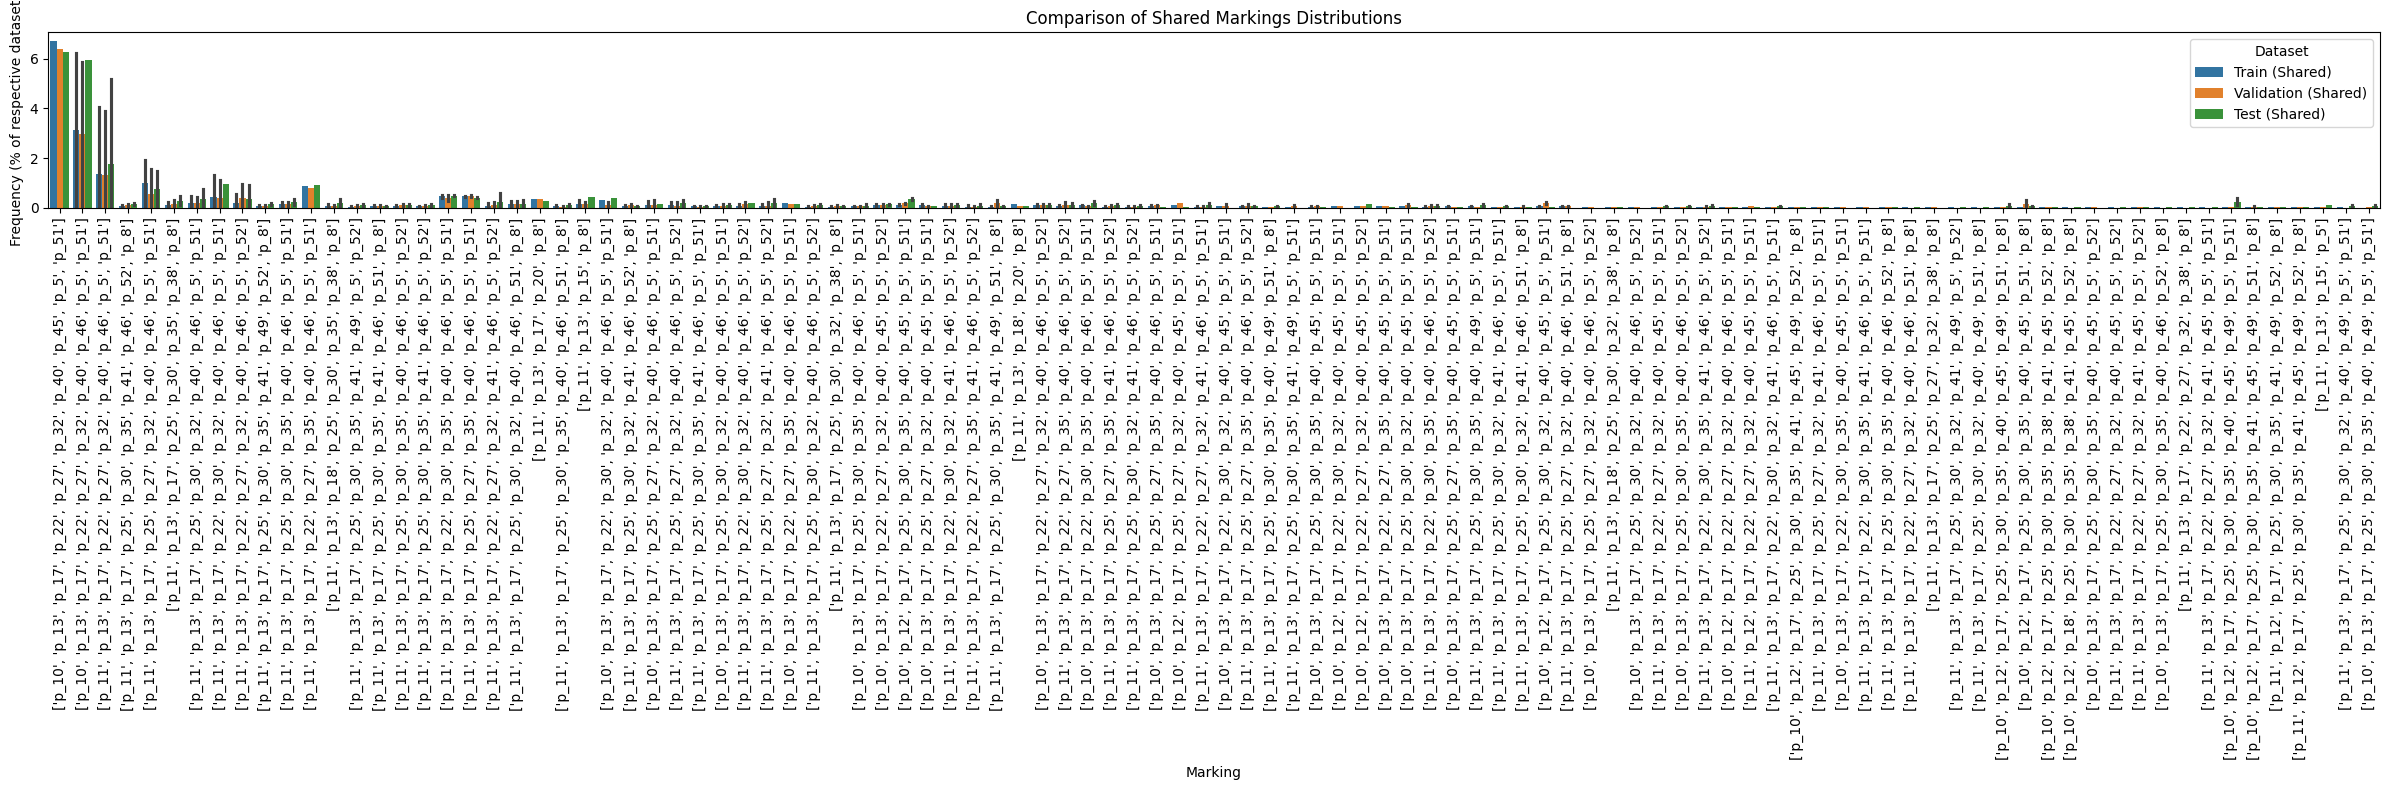

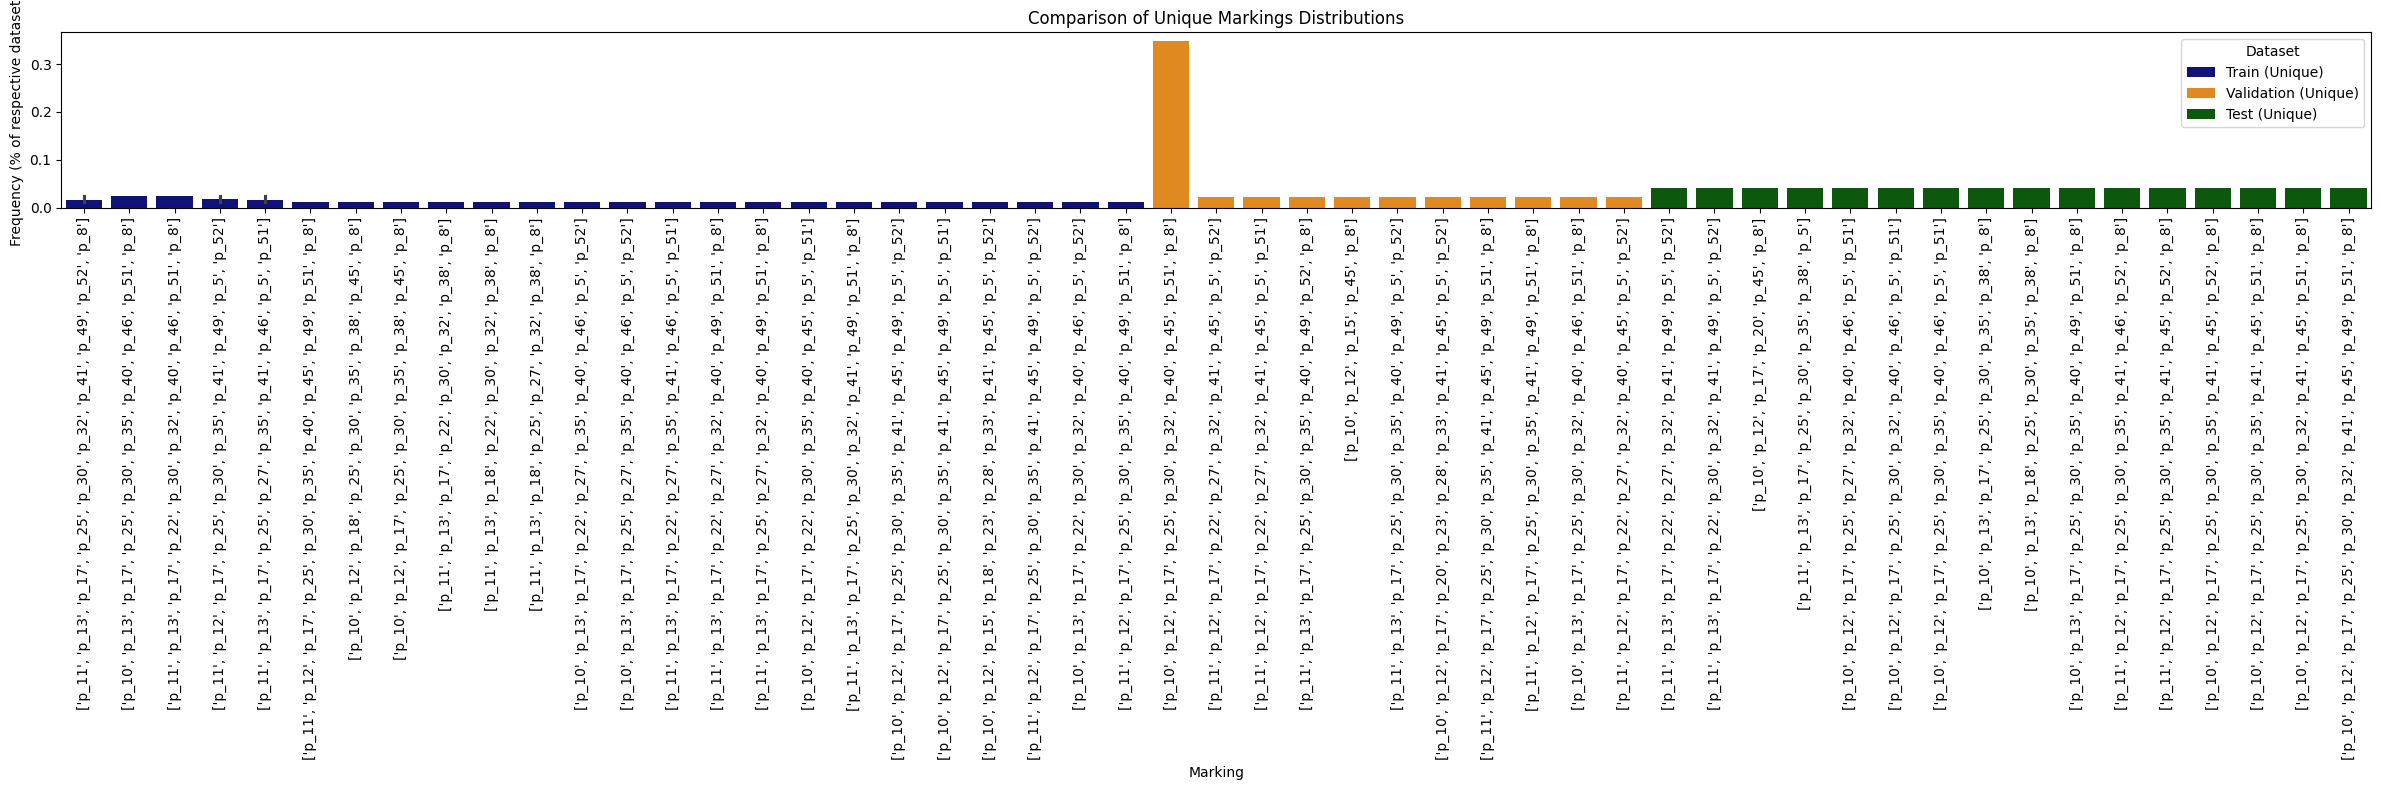

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Process train markings
markings_summary_train['marking_str'] = markings_summary_train['marking'].apply(lambda x: str(sorted([str(i) for i in x])))
markings_summary_train['freq'] = (markings_summary_train['count'] / markings_summary_train['count'].sum()) * 100
markings_summary_train['dataset'] = 'Train'

# Process validation markings
markings_summary_val['marking_str'] = markings_summary_val['marking'].apply(lambda x: str(sorted([str(i) for i in x])))
markings_summary_val['freq'] = (markings_summary_val['count'] / markings_summary_val['count'].sum()) * 100
markings_summary_val['dataset'] = 'Validation'

# Process test markings
markings_summary_test['marking_str'] = markings_summary_test['marking'].apply(lambda x: str(sorted([str(i) for i in x])))
markings_summary_test['freq'] = (markings_summary_test['count'] / markings_summary_test['count'].sum()) * 100
markings_summary_test['dataset'] = 'Test'

# Combine
combined_markings = pd.concat([
    markings_summary_train[['marking_str', 'freq', 'dataset']],
    markings_summary_val[['marking_str', 'freq', 'dataset']], 
    markings_summary_test[['marking_str', 'freq', 'dataset']]
])

# Identify unique markings
train_markings = set(markings_summary_train['marking_str'])
val_markings = set(markings_summary_val['marking_str'])
test_markings = set(markings_summary_test['marking_str'])

def get_category(row):
    m = row['marking_str']
    d = row['dataset']
    unique = False
    if d == 'Train' and m not in val_markings and m not in test_markings:
        unique = True
    elif d == 'Validation' and m not in train_markings and m not in test_markings:
        unique = True
    elif d == 'Test' and m not in train_markings and m not in val_markings:
        unique = True
    
    return f"{d} ({'Unique' if unique else 'Shared'})"

combined_markings['category'] = combined_markings.apply(get_category, axis=1)

# Split into Shared and Unique datasets
shared_data = combined_markings[combined_markings['category'].str.contains('Shared')]
unique_data = combined_markings[combined_markings['category'].str.contains('Unique')]

# Plot 1: Shared Markings
plt.figure(figsize=(24, 8))
palette_shared = {
    'Train (Shared)': 'tab:blue',
    'Validation (Shared)': 'tab:orange', 
    'Test (Shared)': 'tab:green'
}
sns.barplot(data=shared_data, x='marking_str', y='freq', hue='category', palette=palette_shared)
plt.xticks(rotation=90)
plt.title('Comparison of Shared Markings Distributions')
plt.ylabel('Frequency (% of respective dataset)')
plt.xlabel('Marking')
plt.legend(title='Dataset')
plt.tight_layout()
plt.show()

# Unique Markings
plt.figure(figsize=(24, 8))
palette_unique = {
    'Train (Unique)': 'darkblue',
    'Validation (Unique)': 'darkorange',
    'Test (Unique)': 'darkgreen'
}

if not unique_data.empty:
    sns.barplot(data=unique_data, x='marking_str', y='freq', hue='category', palette=palette_unique)
    plt.xticks(rotation=90)
    plt.title('Comparison of Unique Markings Distributions')
    plt.ylabel('Frequency (% of respective dataset)')
    plt.xlabel('Marking')
    plt.legend(title='Dataset')
    plt.tight_layout()
    plt.show()
else:
    print("No unique markings found across datasets.")

In [17]:
# Remove prefixes whose Petri net marking is unique to one split (Train/Val/Test)
"""
(train_pref_df,
val_pref_df,
test_pref_df,
markings_train,
markings_val,
markings_test,
(keep_train_ix, keep_val_ix, keep_test_ix))= pref_adopt_dataframe.remove_prefixes_with_unique_markings(train_pref_df,
                                                                                                        val_pref_df,
                                                                                                        test_pref_df,
                                                                                                        markings_train,
                                                                                                        markings_val,
                                                                                                        markings_test)

print("Kept prefixes (train/val/test):", len(train_pref_df), len(val_pref_df), len(test_pref_df))
"""

'\n(train_pref_df,\nval_pref_df,\ntest_pref_df,\nmarkings_train,\nmarkings_val,\nmarkings_test,\n(keep_train_ix, keep_val_ix, keep_test_ix))= pref_adopt_dataframe.remove_prefixes_with_unique_markings(train_pref_df,\n                                                                                                        val_pref_df,\n                                                                                                        test_pref_df,\n                                                                                                        markings_train,\n                                                                                                        markings_val,\n                                                                                                        markings_test)\n\nprint("Kept prefixes (train/val/test):", len(train_pref_df), len(val_pref_df), len(test_pref_df))\n'

## Store datasets and credentials for Deep-NN

In [18]:
# object to create the tensors for the dnn models and further credentials
el_loader = EventLogLoader(event_log_location=event_log_location, event_log_properties=event_log_properties, prefix_df=pref_adopt_dataframe)

In [19]:
# test
test_set = el_loader.get_encoded_dataframe(type='test')
test_set

,case:concept:name,InfectionSuspected,org:group,DiagnosticBlood,DisfuncOrg,SIRSCritTachypnea,Hypotensie,SIRSCritHeartRate,Infusion,DiagnosticArtAstrup,...,Hypoxie,DiagnosticUrinarySediment,DiagnosticECG,Leucocytes,CRP,LacticAcid,case_elapsed_time,event_elapsed_time,day_in_week,seconds_in_day
0,D,True,A,True,False,True,False,True,True,True,...,False,False,True,NaN,NaN,NaN,0.0,NaN,3.0,42720.0
1,D,NaN,C,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,864.0,864.0,3.0,43584.0
2,D,NaN,A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1494.0,630.0,3.0,44214.0
3,D,NaN,B,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,171.0,NaN,3480.0,1986.0,3.0,46200.0
4,D,NaN,B,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1.6,3480.0,1986.0,3.0,46200.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3171,KNA,NaN,EOS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3172,KNA,NaN,EOS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3173,KNA,NaN,EOS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3174,KNA,NaN,EOS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
# train tensor dataset
train_set = el_loader.get_dataset('train')

# subset to prefixes that remain after unique-marking filtering (if run)
# try:
#     train_set = train_set.subset(keep_train_ix)
# except NameError:
#     pass

# add markings to the train dataset credentials:
train_set.set_prefix_markings(markings=markings_train)

# save dataset 
torch.save(train_set, '../../../../encoded_data_conformance_v2/Sepsis/'+result_name+'_'+str(el_loader.encoder_decoder.min_suffix_size)+'_train.pkl')

categorical tensors:   0%|          | 0/3 [00:00<?, ?it/s]

concept:name:   0%|          | 0/578 [00:00<?, ?it/s]

org:group:   0%|          | 0/578 [00:00<?, ?it/s]

lifecycle:transition:   0%|          | 0/578 [00:00<?, ?it/s]

continouous tensors:   0%|          | 0/7 [00:00<?, ?it/s]

...

seconds_in_day:   0%|          | 0/578 [00:00<?, ?it/s]

Leucocytes:   0%|          | 0/578 [00:00<?, ?it/s]

CRP:   0%|          | 0/578 [00:00<?, ?it/s]

LacticAcid:   0%|          | 0/578 [00:00<?, ?it/s]

static categorical:   0%|          | 0/8213 [00:00<?, ?it/s]

In [21]:
# Test get sizes and others
print("Min suffix size: ", train_set.min_suffix_size)

print("Categories and encoding params for dynamic categorical and continuous values: ", train_set.all_categories)
print("Categories and encoding params for static categorical and continuous values: ", train_set.all_static_categories)

print("Dynamic categorical tensor: ", train_set.categorical_tensors[0].size())
print("Dynamic continuous tensor: ", train_set.continuous_tensors[0].size())

print("Static categorical tensor: ", train_set.static_categorical_tensor.size())
print("Static continuous tensor: ", train_set.static_continuous_tensor.size())

print("Zero padding tensor: ", train_set.zero_padding.size())
print("EOS padding tensor: ",train_set.eos_padding.size())

print("Prefix petri net replay tensor: ", len(train_set.prefixes_petri_net_marking))
print(train_set.prefixes_petri_net_marking[0:3])

Min suffix size:  5
Categories and encoding params for dynamic categorical and continuous values:  ([('concept:name', 18, {'Admission IC': 1, 'Admission NC': 2, 'CRP': 3, 'EOS': 4, 'ER Registration': 5, 'ER Sepsis Triage': 6, 'ER Triage': 7, 'IV Antibiotics': 8, 'IV Liquid': 9, 'LacticAcid': 10, 'Leucocytes': 11, 'Release A': 12, 'Release B': 13, 'Release C': 14, 'Release D': 15, 'Release E': 16, 'Return ER': 17}), ('org:group', 28, {'?': 1, 'A': 2, 'B': 3, 'C': 4, 'D': 5, 'E': 6, 'EOS': 7, 'F': 8, 'G': 9, 'H': 10, 'I': 11, 'J': 12, 'K': 13, 'L': 14, 'M': 15, 'N': 16, 'O': 17, 'P': 18, 'Q': 19, 'R': 20, 'S': 21, 'T': 22, 'U': 23, 'V': 24, 'W': 25, 'X': 26, 'Y': 27}), ('lifecycle:transition', 3, {'EOS': 1, 'complete': 2})], [('case_elapsed_time', 1, {}), ('event_elapsed_time', 1, {}), ('day_in_week', 1, {}), ('seconds_in_day', 1, {}), ('Leucocytes', 1, {}), ('CRP', 1, {}), ('LacticAcid', 1, {})])
Categories and encoding params for static categorical and continuous values:  ([('Age', 16,

In [22]:
# train tensor dataset
val_set = el_loader.get_dataset('val')

# subset to prefixes that remain after unique-marking filtering (if run)
# try:
#     val_set = val_set.subset(keep_val_ix)
# except NameError:
#     pass

# add markings to the train dataset credentials:
val_set.set_prefix_markings(markings=markings_val)

# save dataset 
torch.save(val_set, '../../../../encoded_data_conformance_v2/Sepsis/'+result_name+'_'+str(el_loader.encoder_decoder.min_suffix_size)+'_val.pkl')

categorical tensors:   0%|          | 0/3 [00:00<?, ?it/s]

concept:name:   0%|          | 0/314 [00:00<?, ?it/s]

org:group:   0%|          | 0/314 [00:00<?, ?it/s]

lifecycle:transition:   0%|          | 0/314 [00:00<?, ?it/s]

continouous tensors:   0%|          | 0/7 [00:00<?, ?it/s]

...

seconds_in_day:   0%|          | 0/314 [00:00<?, ?it/s]

Leucocytes:   0%|          | 0/314 [00:00<?, ?it/s]

CRP:   0%|          | 0/314 [00:00<?, ?it/s]

LacticAcid:   0%|          | 0/314 [00:00<?, ?it/s]

static categorical:   0%|          | 0/4586 [00:00<?, ?it/s]

In [23]:
# Test get sizes and others
print("Min suffix size: ", val_set.min_suffix_size)

print("Categories and encoding params for dynamic categorical and continuous values: ", val_set.all_categories)
print("Categories and encoding params for static categorical and continuous values: ", val_set.all_static_categories)

print("Dynamic categorical tensor: ", val_set.categorical_tensors[0].size())
print("Dynamic continuous tensor: ", val_set.continuous_tensors[0].size())

print("Static categorical tensor: ", val_set.static_categorical_tensor.size())
print("Static continuous tensor: ", val_set.static_continuous_tensor.size())

print("Zero padding tensor: ", val_set.zero_padding.size())
print("EOS padding tensor: ",val_set.eos_padding.size())

print("Prefix petri net replay tensor: ", len(val_set.prefixes_petri_net_marking))
print(val_set.prefixes_petri_net_marking[0:3])

Min suffix size:  5
Categories and encoding params for dynamic categorical and continuous values:  ([('concept:name', 18, {'Admission IC': 1, 'Admission NC': 2, 'CRP': 3, 'EOS': 4, 'ER Registration': 5, 'ER Sepsis Triage': 6, 'ER Triage': 7, 'IV Antibiotics': 8, 'IV Liquid': 9, 'LacticAcid': 10, 'Leucocytes': 11, 'Release A': 12, 'Release B': 13, 'Release C': 14, 'Release D': 15, 'Release E': 16, 'Return ER': 17}), ('org:group', 28, {'?': 1, 'A': 2, 'B': 3, 'C': 4, 'D': 5, 'E': 6, 'EOS': 7, 'F': 8, 'G': 9, 'H': 10, 'I': 11, 'J': 12, 'K': 13, 'L': 14, 'M': 15, 'N': 16, 'O': 17, 'P': 18, 'Q': 19, 'R': 20, 'S': 21, 'T': 22, 'U': 23, 'V': 24, 'W': 25, 'X': 26, 'Y': 27}), ('lifecycle:transition', 3, {'EOS': 1, 'complete': 2})], [('case_elapsed_time', 1, {}), ('event_elapsed_time', 1, {}), ('day_in_week', 1, {}), ('seconds_in_day', 1, {}), ('Leucocytes', 1, {}), ('CRP', 1, {}), ('LacticAcid', 1, {})])
Categories and encoding params for static categorical and continuous values:  ([('Age', 16,

In [24]:
# train tensor dataset
test_set = el_loader.get_dataset('test')

# subset to prefixes that remain after unique-marking filtering (if run)
# try:
#     test_set = test_set.subset(keep_test_ix)
# except NameError:
#     pass

# add markings to the train dataset credentials:
test_set.set_prefix_markings(markings=markings_test)

# save dataset 
torch.save(test_set, '../../../../encoded_data_conformance_v2/Sepsis/'+result_name+'_'+str(el_loader.encoder_decoder.min_suffix_size)+'_test.pkl')

categorical tensors:   0%|          | 0/3 [00:00<?, ?it/s]

concept:name:   0%|          | 0/157 [00:00<?, ?it/s]

org:group:   0%|          | 0/157 [00:00<?, ?it/s]

lifecycle:transition:   0%|          | 0/157 [00:00<?, ?it/s]

continouous tensors:   0%|          | 0/7 [00:00<?, ?it/s]

...

seconds_in_day:   0%|          | 0/157 [00:00<?, ?it/s]

Leucocytes:   0%|          | 0/157 [00:00<?, ?it/s]

CRP:   0%|          | 0/157 [00:00<?, ?it/s]

LacticAcid:   0%|          | 0/157 [00:00<?, ?it/s]

static categorical:   0%|          | 0/2391 [00:00<?, ?it/s]

In [25]:
# Test get sizes and others
print("Min suffix size: ", test_set.min_suffix_size)

print("Categories and encoding params for dynamic categorical and continuous values: ", test_set.all_categories)
print("Categories and encoding params for static categorical and continuous values: ", test_set.all_static_categories)

print("Dynamic categorical tensor: ", test_set.categorical_tensors[0].size())
# print("Dynamic categorical tensor examples: ", test_set.categorical_tensors[0][10:55])
print("Dynamic continuous tensor: ", test_set.continuous_tensors[0].size())

print("Static categorical tensor: ", test_set.static_categorical_tensor.size())
print("Static continuous tensor: ", test_set.static_continuous_tensor.size())

print("Zero padding tensor: ", test_set.zero_padding.size())
print("EOS padding tensor: ",test_set.eos_padding.size())
# print("Zero padds: ", test_set.zero_padding[35:41])
# print("EOS padds: ", test_set.eos_padding[35:41])

print("Prefix petri net replay tensor: ", len(test_set.prefixes_petri_net_marking))
print(test_set.prefixes_petri_net_marking[0:3])

Min suffix size:  5
Categories and encoding params for dynamic categorical and continuous values:  ([('concept:name', 18, {'Admission IC': 1, 'Admission NC': 2, 'CRP': 3, 'EOS': 4, 'ER Registration': 5, 'ER Sepsis Triage': 6, 'ER Triage': 7, 'IV Antibiotics': 8, 'IV Liquid': 9, 'LacticAcid': 10, 'Leucocytes': 11, 'Release A': 12, 'Release B': 13, 'Release C': 14, 'Release D': 15, 'Release E': 16, 'Return ER': 17}), ('org:group', 28, {'?': 1, 'A': 2, 'B': 3, 'C': 4, 'D': 5, 'E': 6, 'EOS': 7, 'F': 8, 'G': 9, 'H': 10, 'I': 11, 'J': 12, 'K': 13, 'L': 14, 'M': 15, 'N': 16, 'O': 17, 'P': 18, 'Q': 19, 'R': 20, 'S': 21, 'T': 22, 'U': 23, 'V': 24, 'W': 25, 'X': 26, 'Y': 27}), ('lifecycle:transition', 3, {'EOS': 1, 'complete': 2})], [('case_elapsed_time', 1, {}), ('event_elapsed_time', 1, {}), ('day_in_week', 1, {}), ('seconds_in_day', 1, {}), ('Leucocytes', 1, {}), ('CRP', 1, {}), ('LacticAcid', 1, {})])
Categories and encoding params for static categorical and continuous values:  ([('Age', 16,